<a href="https://colab.research.google.com/github/22f1001276/MLP/blob/main/mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP Project
- Excellent wine company wants to develop ML model for predicting wine quality on certain physiochemical characteristic in order to replace expensive quality sensor.
- Let's understand steps involved in addressing this problem.

### Steps in ML projects
There are eight steps in ML projects
- Look at the big picture
- Get the data
- Discover and visualize the data to gain insights
- Prepare the data for Machine Learning algorithms
- Select a model and train it
- Fine-tune your model
- Present your solution
- Launch, monitor and maintain your system

### Step 1: Look at big picture


1.   Frame the problem
2.   Select a performance measure
3.   List and check the assumptions

  1.1 Frame the problem
  - What is input and output?
  - What is the business objective? How does company expects to use and benefit from the model?
      - Useful in problem framing
      - Algorithm and performance measure selection
      - Overall effort estimation
  - What is the current solution (if any)?
      - Provides a useful baseline

*Design consideration in problem framing*
- Is this a supervised, unsupervised or a RL problem?
- Is this a classification, regression or some other task?
- What is the nature of the output: single or multiple outputs?
- Does the system need continuous learning or periodic updates?
- What would be the learning style: batch or online?

  1.2 Selection of performance measure
  - Regression
    - Mean Squared Error (MSE) or
    - Mean Absolute Error (MAE)
  - Classification
    - Precision
    - Recall
    - F1-score
    - Accuracy

  1.3 Check the assumptions
  - List down various assumptions about the task
  - Review with domain experts and other teams that plan to consume ML output
  - Make sure all assumptions are reviewed and approved before coding!






### Step 2: Get the data
- Data spread across multiple tables, files or documents with access control
- Obtain appropriate access controls and authorizations
- Get familiarized with data by looking at schema and few rows. (Familiarity with SQL would be useful here.)
- Load basic libraries (pandas, numpy, matplotlib, seaborn)


- Let's first access our data - in this case, we need to download it from the web.
- It's a good practice to create a function for downloading and extracting the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# getting data
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
data = pd.read_csv(data_url, sep=";")

#### 2.1 Check data samples

In [ ]:
# now let's examine it
data.head()   # give first 5 rows of DataFrame

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


#### 2.2 Features
It's a good idea to understand significance of each feature by consulting the experts.

In [ ]:
feature_list = data.columns[:-1].values
label = [data.columns[-1]]

print(f"Features: {feature_list}")
print(f"Label: {label}")

Features: ['fixed acidity' 'volatile acidity' 'citric acid' 'residual sugar'
 'chlorides' 'free sulfur dioxide' 'total sulfur dioxide' 'density' 'pH'
 'sulphates' 'alcohol']
Label: ['quality']


#### 2.3 Data statistics
Let's use *info()* method to get quick description of data.
- Total entries: 1599 (Tiny dataset by ML standard)
- There are 12 columns: 11 features + 1 label
  - Label column: quality
  - Features: remaining 11 (except quality)
  - All columns are numeric (float64) and label is an integer

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
# in order to understand nature of numeric attributes, we use describe() method
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


- The win quality can be between 0 to 10, but in this dataset, the quality values are between 3 and 8. Let's look at the distribution of examples by the wine quality
- High quality value --> better quality of wine
- You can see that there are lots of samples of average wines than good or the poor quality ones
  - Many examples with quality = 5 or 6

In [ ]:
data['quality'].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


The information can be viewed through histogram plot.
- A Histogram gives the ocunt of how many samples occurs within a specific range (bins).
- The x-axis denotes the range of values in a feature and
- The y-axis denotes the frequency of samples with those specific values

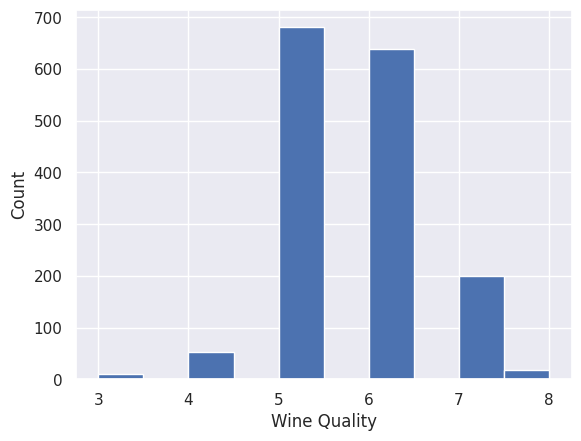

In [ ]:
sns.set()
data.quality.hist()
plt.xlabel('Wine Quality')
plt.ylabel('Count')
plt.show()

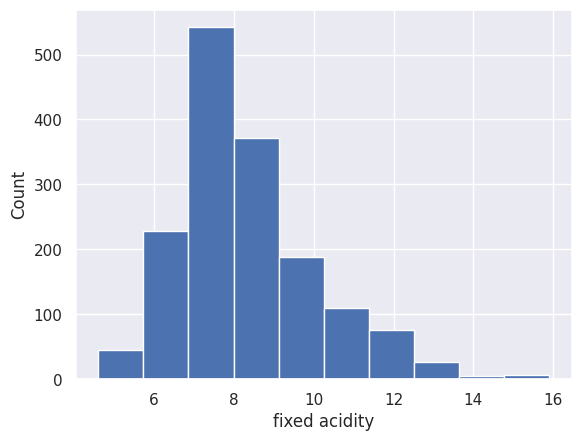

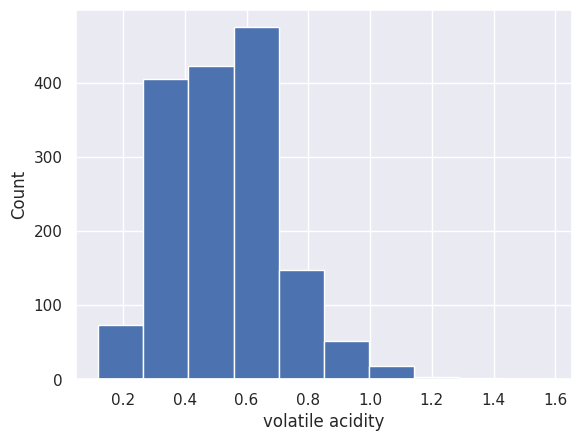

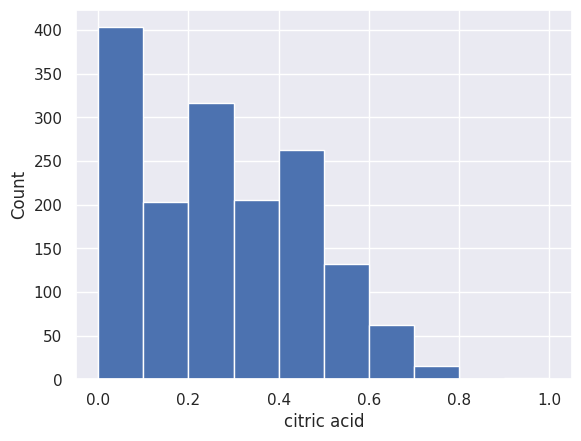

In [ ]:
columns = data.columns[:-1]
for col in columns:
  data[col].hist()
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.show()

A few observations based on these plots.
1. Features are at different scales.
2. Features have different distributions -
  - A few are tail heavy. e.g. residual sugar, free so2
  - A few have multiple modes. e.g. volatile acidity, citric acid

#### 2.4 Create test set
- When we look at the test set, we are likely to notice patterns in that and based on that we may select certain models.
- this leads to biased estimation on test set, which may not generalize well in practice. This is called **data snooping bias**


Let's write a function to split the data into training and test. Make sure to set the seed so that we get the same test set in the next run.

In [ ]:
def split_train_test(data, test_ratio):
  # set the random seed
  np.random.seed(42)

  # shuffle the dataset
  shuffled_indices = np.random.permutation(len(data))

  # calculate the size of the test set
  test_set_size = int(len(data) * test_ratio)

  #split the dataset to get training and test sets
  test_indices = shuffled_indices[:test_set_size]
  train_indices = shuffled_indices[test_set_size:]
  return data.iloc[train_indices], data.iloc[test_indices]

In [ ]:
train_set, test_set = split_train_test(data, 0.2)

Scikit-Learn provides a few functions for creating test sets based on
1. **Random Sampling**, which randomly select *k%* points in the test set.
2. **Stratified sampling**, which samples test examples such that they are representative of overall distribution


**Random Sampling**
- train_test_split() function perfroms random sampling with
  - **random_state** parameter to set the random seed, which ensures that the same examples are selected for test sets across runs.
  - **test_size** parameter for specifying size of the test set.
  - **shuffle flag** to specify if the data needs to be shuffled before splitting.
- Provision for processing multiple datasets with an identical number of rows and selecting the same indices from these datasets.
  - Useful when labels are in different dataframe

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# we can read documentation for this function by using the following line of code:
# ?train_test_split

In [ ]:
# let's perform random sampling on our dataset:
train_set, test_set = train_test_split(data, test_size=0.2, random_state=42)

**Stratified sampling**
- Data distribution may not be uniform in real world data.
- Random sampling - by its nature - introduces biases in such data sets.

Recall the label distribution in out dataset: it's not uniform
- Many examples of class 5 or 6 compared to the other classes.
- This causes a problem while random sampling. The test distribution may not match with the overall distribution.

*How do we sample in such cases?*
- We divide the population into homogenous groups called **strata**.
- Data is sampled from each stratum so as to match it with the overall data distribution.
- Scikit-Learn provides a class ***StratifiedShuffleSplit*** that helps us in stratified sampling.


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(data, data['quality']):
  strat_train_set = data.loc[train_index]
  strat_test_set = data.loc[test_index]

### Step 3: Data visualization
- Performed on training set
- In case of large training set -
  - Sample examples to form **exploration set**
- Enables to understand features and their relationship among themselves and with output label.

In our case, we have a small training data and we use it all for data exploration. There is no need to create a separate exploration set.

It's a good idea to create a copy of the training set so that we can freely manipulate it without worrying about any manipulation in the original set.

In [ ]:
exploration_set = strat_train_set.copy()

In [ ]:
# Scatter visualization
# with seaborn library:
sns.scatterplot(x='fixed acidity', y='density', hue='quality', data=exploration_set)

In [ ]:
# with matplotlib
exploration_set.plot(kind='scatter', x='fixed acidity', y='density', alpha=0.5, c='quality', cmap=plt.get_cmap('jet'))

Relationship between features
- **Standard correlation coeffient** between features.
  - Ranges between -1 to +1
    - **Correlation = +1**: Strong positive correlation between features
    - **Correlation = -1**: Strong negative correlation between features
    - **Correlation = 0**: No linear correlation between features
- Visualize with heat map
  - For non-linear relationship, use **rank correlation**


Let's calculate correlations between our features.

In [ ]:
corr_matrix = exploration_set.corr()

In [ ]:
# Let's check features that are correlated with the label, which is quality in our case.
corr_matrix['quality']

In [ ]:
# Let's visualize correlation matrix with heatmap:
plt.figure(figsize=(14,7))
sns.heatmap(corr_matrix, annot=True)

In [ ]:
# another option to visualize the relationship between the features is with scatter matrix
from pandas.plotting import scatter_matrix
attribute_list = ['citric acid', 'pH', 'alcohol', 'sulphates', 'quality']
scatter_matrix(exploration_set[attribute_list])

### Step 4: Prepare data for ML algorithm
We often need to preprocess the data before using it for model building due to variety of reasons:
- Due to errors in data capture, data may contain outliers or missing values
- Different features may be at different scales
- The current data distribution is not exactly amenable to learning

Typical steps in data preprocessing are as follows:
1. Separate features and labels
2. Handling missing values and outliers
3. Feature scaling to bring all features on the same scale
4. Applying certain transformations like log, square root on the features

*Note:* It's good to make a copy of data and apply preprocessing on that copy so that we can have original data if anything goes wrong.

#### 4.1 Separate features and labels from the training set

In [ ]:
# copy features leaving aside the label
wine_features = strat_train_set.drop('quality', axis=1)

# copy the label list
wine_labels = strat_train_set['quality'].copy()

#### 4.2 Data cleaning
Let's first check if there are any missing values in feature set: One way to find out that is column-wise.

In [ ]:
wine_features.isna().sum()  # counts the number of NaN in each column of wine_features

In case, we have non-zero numbers in any columns, we have a problem of missing values.
- These values are missing due to errors in recording or they do not exist.
- If they are not recorded:
  - Use imputation technique to fill up the missing values
  - Drop the rows containing missing values
- If they do not exists, it is better to keep it as NaN

Sklearn provides the following methods to drop rows containing missing values:  
- ***dropna()***  
- ***drop()***

It provides *SimpleImputer* class for filling up missing values with. say, median value.

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
# strategy contains instructions as how to replace the missing values. In this case,
# we specify that the missing value should be replaced by the median value

In [ ]:
imputer.fit(wine_features)

In [ ]:
# Let's check the statistics learnt by imputer on the training set:
imputer.statistics_  # return median values for each feature

In [ ]:
# we can cross-check it by calculation median on the feature set:
wine_features.median()

Finally we use the trained imputer to transform the training set such that the missing values are replaced by the medians:

In [ ]:
tr_features = imputer.transform(wine_features)

This returns a Numpy array and we can convert it to the dataframe if needed:

In [ ]:
tr_features.shape

In [ ]:
wine_features_tr = pd.DataFrame(tr_features, columns=wine_features.columns)  # return dataframe after transformation

#### 4.3 Handling text and categorical attributes
4.3.1 Converting categories to numbers:

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

- Call *fit_tranform()* method on *ordinal_encoder* object to convert text to numbers.
- The list of categories can be obtain via *categories_instance* variable.

One issue with this representation is that the ML algorithm would assume that the two nearby values are closer than the distinct ones.

4.3.2 Using one hot encoding
- Here we create one binary feature per category - the feature value is 1 when the category present else it is 0.
- Only one feature is 1 (hot) and the rest are 0 (cold)
- The new features are referred to as dummy features.
- Scikit-Learn provides a *OneHotEncoder* class to convert categorical values into one-hot vectors.

- We need to call *fit_transform()* method on *OneHotEncoder* object.
- The output is a SciPy sparse matrix rather than NumPy array. This enables us to save space when we have a huge number of categories.
- In case we want to convert it to dense representation, we can do so with *toarray()*
method.
- The list of categories can be obtained via *categories_* instance variable

In [ ]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()

- As we observed that when the number of categories are very large, the one-hot encoding would result in a very large number of features.
- This can be addressed with one of the following approaches:
  - Replace with categorical numerical features
  - Convert into low-dimensional learnable vectors called *embeddings*
  

#### 4.4 Feature Scaling
- Most ML algorithms do not perform well when input features are on very different scales.
- Scaling of target label is generally not required


4.4.1 Min-Max scaling or Normalization
- We subtract minimum value of a feature from the current value and divide it by the difference between the minimum and the maximum value of that feature
- Values are shifted and scaled so that they range between 0 and 1.
- Scikit-Learn provides *MinMaxScalar* transformer for this.
- One can specify hyperparameter *feature_range* to specify the range of the feature.

4.4.2 Standardization
- We subtract mean value of each feature from the current value and divide it by the standard deviation so that the resulting feature has a unit variance
- While normalization bounds values between 0 and 1, standardization does not bound values to a specific range.